# YOLO로 감지된 이미지 LLM으로 설명하기

In [1]:
!pip install langchain
!pip install langchain-openai
!pip install langchain-community
!pip install langchain-core
!pip install ultralytics
!pip install opencv-python
!pip install python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.5 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━

In [3]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
from ultralytics import YOLO
import os
import cv2
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import base64

from dotenv import load_dotenv


load_dotenv()

api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    raise RuntimeError("OPENAI_API_KEY가 없어요")

In [11]:
# 작업 1 : YOLO
MODEL_NAME = "yolo11n.pt"
IMAGE_PATH = 'persons.jpeg'
SAVE_DIR = 'corpped'
CONF_THRESHOLD = 0.3

if not os.path.exists(IMAGE_PATH):
  raise FileNotFoundError(f"이미지 파일 없음 : {IMAGE_PATH}")

model = YOLO(MODEL_NAME)

image = cv2.imread(IMAGE_PATH)
if image is None:
  raise ValueError(f'이미지 로딩 실패')

os.makedirs(SAVE_DIR, exist_ok=True)

# 폴더에 기존 이미지 삭제
for old_file in Path(SAVE_DIR).glob('person*.*'):
  old_file.unlink()

# 이미지 객체 감지
results = model(image)
# print(result)

person_count = 0
saved_path = []
# 감지된 객체 처리하기
for result in results:
  for box in result.boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0]) # 박스 좌표 추출
    cls_id = int(box.cls[0]) # 클래스 ID 추출
    label = result.names[cls_id]
    confidence = float(box.conf[0]) # 신뢰도 추출

    if label.lower() != 'person':continue
    if confidence < CONF_THRESHOLD:continue

    # 좌표 보정하기 이미지 범위를 벗어나지 않게
    h, w = image.shape[:2]
    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(w, x2)
    y2 = min(h, y2)

    if x2 <= x1 or y2 <= y1: continue # 잘못된 box 제외

    cropped = image[y1:y2, x1:x2]
    person_count += 1
    crop_filename = os.path.join(SAVE_DIR, f'person{person_count}.jpeg')

    cv2.imwrite(crop_filename, cropped)
    saved_path.append(crop_filename)
    print(f"저장 성공 : {crop_filename} / conf = {confidence:.2f}")

print("총 감지된 사람 수: ", person_count)


0: 448x640 4 persons, 3 skateboards, 219.6ms
Speed: 9.3ms preprocess, 219.6ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)
저장 성공 : corpped/person1.jpeg / conf = 0.93
저장 성공 : corpped/person2.jpeg / conf = 0.90
저장 성공 : corpped/person3.jpeg / conf = 0.90
저장 성공 : corpped/person4.jpeg / conf = 0.89
총 감지된 사람 수:  4


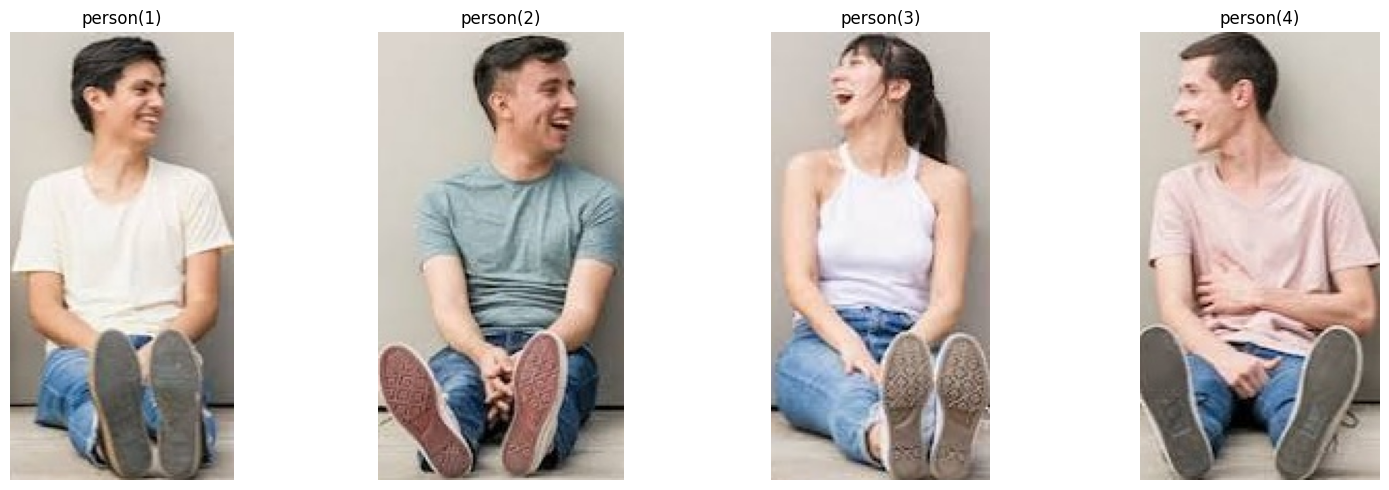

In [14]:
# 저장된 이미지 출력하기
if person_count == 0:
  print("출력 할 이미지 없음")
else:
  fig, axes = plt.subplots(1, person_count, figsize=(4 * person_count, 5))
  if person_count == 1:
    axes = [axes]

  for i, img_Path in enumerate(saved_path):
    img = mpimg.imread(img_Path)
    axes[i].imshow(img)
    axes[i].set_title(f"person({i + 1})")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

In [17]:
# 작업 2 : LangChain + LLM

llm = ChatOpenAI(model="gpt-4.1-mini", temperature="0.7")

prompt_text = (
    "이 이미지를 보고 사람의 의상, 자세, 배경 등에 대해 상세히 설명해"
)

# 이미지를 base64 Data url 형식으로 변환
def encode_image_to_data_url(image_path:str) -> str:
    ext = Path(image_path).suffix.lower().replace(".","")
    if ext == "jpg": ext="jpeg"
    if not ext:ext='jpeg'

    with open(image_path, "rb") as f:
        encoding_image = base64.b64encode(f.read()).decode("utf-8")

    return f"data:image/{ext};base64,{encoding_image}"

# print(encode_image_to_data_url("persons.jpeg"))

for i in range(1, person_count + 1):
  image_path = f"{SAVE_DIR}/person{i}.jpeg"

  # 이미지 파일 존재 여부
  if not os.path.exists(image_path):
    print(f"{image_path} 파일 없음")
    continue

  img_url = encode_image_to_data_url(image_path)

  # Multi Modal Message
  message = HumanMessage(
      content = [
          {
              "type": "text",
              "text": prompt_text
          },
          {
              "type": "image_url",
              "image_url": {"url": img_url}
          }
      ]
  )

  response = llm.invoke([message])

  print(f"\npreson{i}.jpeg 설명 : {response.content.strip()}")


preson1.jpeg 설명 : 이 이미지에는 밝은 표정을 짓고 있는 한 남성이 앉아 있는 모습이 담겨 있습니다. 그는 흰색 반팔 티셔츠를 입고 있으며, 하의는 파란색 청바지를 착용하고 있습니다. 신발은 어두운 색 계열로 보이며, 발바닥 쪽이 화면을 향해 있어 신발 밑창이 잘 보입니다. 남성은 벽이나 평평한 표면에 기대어 앉아 있고, 상체는 약간 옆으로 돌린 자세이며, 머리는 오른쪽을 향해 있습니다. 배경은 단색의 밝은 회색 벽으로 특별한 장식이나 요소 없이 매우 단순하고 깔끔한 편입니다. 전체적으로 편안하고 자연스러운 분위기가 느껴집니다.

preson2.jpeg 설명 : 이미지에는 밝은 회색 벽 앞에 앉아 있는 남성이 보입니다. 그는 짧은 머리를 가지고 있으며, 회색 반팔 티셔츠와 청색 데님 바지를 입고 있습니다. 신발은 붉은색 바닥을 가진 운동화로 보입니다. 남성은 다리를 앞으로 뻗은 채 바닥에 앉아 있고, 두 손은 무릎 위에서 맞잡고 있습니다. 그는 몸을 약간 오른쪽으로 돌려 웃으며 옆을 바라보고 있습니다. 배경은 단색의 벽으로 단순하고 깔끔한 느낌을 줍니다. 전체적으로 편안하고 자연스러운 자세와 표정을 하고 있는 모습입니다.

preson3.jpeg 설명 : 이 이미지는 흰색 민소매 탑과 청바지를 입은 여성이 바닥에 앉아 있는 모습을 보여줍니다. 여성은 다리를 앞으로 뻗고 발바닥이 카메라 쪽으로 향해 있으며, 신발은 회색 톤의 운동화입니다. 그녀는 오른손으로 왼쪽 손목을 잡고 있고, 고개를 왼쪽으로 돌려 크게 웃고 있는 표정을 짓고 있습니다. 배경은 단색의 밝은 회색 또는 베이지 톤으로, 특별한 무늬나 물체가 없는 심플한 배경입니다. 전체적으로 편안하고 자연스러운 분위기를 주는 이미지입니다.

preson4.jpeg 설명 : 이 이미지에는 벽에 기대어 바닥에 앉아 있는 남성이 보입니다. 그는 연한 분홍색의 반소매 티셔츠를 입고 있으며, 청바지를 착용하고 있습니다. 신발은 회색 바닥에 흰색 밑창이 보이는 스니커즈로 보입니다. 남성은 왼쪽을 바라보며 크